<h1 style="color: #00BFFF;">Web Scraping REAL</h1>

![legtsgo](https://i.giphy.com/media/v1.Y2lkPTc5MGI3NjExOGllM2RkeHVmM3diZ2Mzdzhydm00MjFrbW8zMWgwNHEzbTl5eGEyMiZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/fJKG1UTK7k64w/giphy.gif)

<h2 style="color: #008080;">Web Scraping con Python</h2>

En esta lección, usaremos la librería `requests` para obtener páginas web y `Beautiful Soup` del paquete `bs4` para analizar esas páginas y extraer información.


<h1 style="color: #00BFFF;">00 | Caso de Uso 1</h1>

In [1]:
# pip install requests

In [7]:
# 📚 Librerías básicas
import pandas as pd

#❗Librerías NUEVAS!
from bs4 import BeautifulSoup
import requests

# ⚙️ Settings
pd.set_option('display.max_columns', None) # para ver todas las columnas
pd.set_option('display.max_colwidth', 500)
import warnings
warnings.filterwarnings('ignore') # ignorar warnings

<h1 style="color: #00BFFF;">01 | Data Extraction</h1>

Vamos a https://books.toscrape.com/, donde veremos una colección de libros.  
Observa que cada libro tiene los siguientes elementos:

- Título
- Precio

Nuestro objetivo será extraer esta información mediante web scraping y almacenarla en un dataframe de pandas.


In [9]:
# guardamos el link en una variable
link = "https://books.toscrape.com/"

In [11]:
response = requests.get(link)
response.status_code # 200 status code significa OK!

200

In [13]:
response

<Response [200]>

In [15]:
html = response.text
html

'<!DOCTYPE html>\n<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->\n<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->\n<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->\n<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->\n    <head>\n        <title>\n    All products | Books to Scrape - Sandbox\n</title>\n\n        <meta http-equiv="content-type" content="text/html; charset=UTF-8" />\n        <meta name="created" content="24th Jun 2016 09:29" />\n        <meta name="description" content="" />\n        <meta name="viewport" content="width=device-width" />\n        <meta name="robots" content="NOARCHIVE,NOCACHE" />\n\n        <!-- Le HTML5 shim, for IE6-8 support of HTML elements -->\n        <!--[if lt IE 9]>\n        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>\n        <![endif]-->\n\n        \n            <link rel="shortcut icon" href

In [17]:
soup = BeautifulSoup(html, 'html.parser')
soup

<!DOCTYPE html>

<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html class="no-js" lang="en-us"> <!--<![endif]-->
<head>
<title>
    All products | Books to Scrape - Sandbox
</title>
<meta content="text/html; charset=utf-8" http-equiv="content-type"/>
<meta content="24th Jun 2016 09:29" name="created"/>
<meta content="" name="description"/>
<meta content="width=device-width" name="viewport"/>
<meta content="NOARCHIVE,NOCACHE" name="robots"/>
<!-- Le HTML5 shim, for IE6-8 support of HTML elements -->
<!--[if lt IE 9]>
        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>
        <![endif]-->
<link href="static/oscar/favicon.ico" rel="shortcut icon"/>
<link href="static/oscar/css/styles.css" rel="stylesheet" type="text/css"/>
<link href="s

<h2 style="color: #008080;">Coger todos los títulos de los libros</h2>

In [19]:
### Explora la web y mira cómo podemos sacar los titulos de los libros
lista_h3 = soup.find_all("h3") 
lista_h3

[<h3><a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">A Light in the ...</a></h3>,
 <h3><a href="catalogue/tipping-the-velvet_999/index.html" title="Tipping the Velvet">Tipping the Velvet</a></h3>,
 <h3><a href="catalogue/soumission_998/index.html" title="Soumission">Soumission</a></h3>,
 <h3><a href="catalogue/sharp-objects_997/index.html" title="Sharp Objects">Sharp Objects</a></h3>,
 <h3><a href="catalogue/sapiens-a-brief-history-of-humankind_996/index.html" title="Sapiens: A Brief History of Humankind">Sapiens: A Brief History ...</a></h3>,
 <h3><a href="catalogue/the-requiem-red_995/index.html" title="The Requiem Red">The Requiem Red</a></h3>,
 <h3><a href="catalogue/the-dirty-little-secrets-of-getting-your-dream-job_994/index.html" title="The Dirty Little Secrets of Getting Your Dream Job">The Dirty Little Secrets ...</a></h3>,
 <h3><a href="catalogue/the-coming-woman-a-novel-based-on-the-life-of-the-infamous-feminist-victoria-woodhull_993/ind

In [21]:
len(lista_h3)

20

In [27]:
lista_h3[10].text

'Starving Hearts (Triangular Trade ...'

In [29]:
# Pruebo de hacer las cosas en un elemento
test = lista_h3[0]
test.find("a").get("title")

'A Light in the Attic'

In [31]:
test.a.get("title")

'A Light in the Attic'

In [33]:
titulos = []
for elemento in lista_h3:
    titulos.append(elemento.a.get("title"))

len(titulos)

20

In [35]:
titulos

['A Light in the Attic',
 'Tipping the Velvet',
 'Soumission',
 'Sharp Objects',
 'Sapiens: A Brief History of Humankind',
 'The Requiem Red',
 'The Dirty Little Secrets of Getting Your Dream Job',
 'The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull',
 'The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics',
 'The Black Maria',
 'Starving Hearts (Triangular Trade Trilogy, #1)',
 "Shakespeare's Sonnets",
 'Set Me Free',
 "Scott Pilgrim's Precious Little Life (Scott Pilgrim #1)",
 'Rip it Up and Start Again',
 'Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991',
 'Olio',
 'Mesaerion: The Best Science Fiction Stories 1800-1849',
 'Libertarianism for Beginners',
 "It's Only the Himalayas"]

In [ ]:
### Maneras de hacerlo

In [37]:
# Opcion facil
lista_titulos = []
for elemento in lista_h3:
    lista_titulos.append(elemento.get_text())
lista_titulos

['A Light in the ...',
 'Tipping the Velvet',
 'Soumission',
 'Sharp Objects',
 'Sapiens: A Brief History ...',
 'The Requiem Red',
 'The Dirty Little Secrets ...',
 'The Coming Woman: A ...',
 'The Boys in the ...',
 'The Black Maria',
 'Starving Hearts (Triangular Trade ...',
 "Shakespeare's Sonnets",
 'Set Me Free',
 "Scott Pilgrim's Precious Little ...",
 'Rip it Up and ...',
 'Our Band Could Be ...',
 'Olio',
 'Mesaerion: The Best Science ...',
 'Libertarianism for Beginners',
 "It's Only the Himalayas"]

In [39]:
# Opcion un poco mas complicada
lista_titulos_2 = []
for elemento in lista_h3:
    titulo = elemento.find("a").get("title")
    lista_titulos_2.append(titulo)
lista_titulos_2

['A Light in the Attic',
 'Tipping the Velvet',
 'Soumission',
 'Sharp Objects',
 'Sapiens: A Brief History of Humankind',
 'The Requiem Red',
 'The Dirty Little Secrets of Getting Your Dream Job',
 'The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull',
 'The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics',
 'The Black Maria',
 'Starving Hearts (Triangular Trade Trilogy, #1)',
 "Shakespeare's Sonnets",
 'Set Me Free',
 "Scott Pilgrim's Precious Little Life (Scott Pilgrim #1)",
 'Rip it Up and Start Again',
 'Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991',
 'Olio',
 'Mesaerion: The Best Science Fiction Stories 1800-1849',
 'Libertarianism for Beginners',
 "It's Only the Himalayas"]

In [41]:
# METODO 1 (facil)
for a in soup.find_all("h3"):
    print(a.get_text())

A Light in the ...
Tipping the Velvet
Soumission
Sharp Objects
Sapiens: A Brief History ...
The Requiem Red
The Dirty Little Secrets ...
The Coming Woman: A ...
The Boys in the ...
The Black Maria
Starving Hearts (Triangular Trade ...
Shakespeare's Sonnets
Set Me Free
Scott Pilgrim's Precious Little ...
Rip it Up and ...
Our Band Could Be ...
Olio
Mesaerion: The Best Science ...
Libertarianism for Beginners
It's Only the Himalayas


In [43]:
# METODO 2 (facil)
titles = [titulo.get_text() for titulo in soup.find_all("h3")]
titles

['A Light in the ...',
 'Tipping the Velvet',
 'Soumission',
 'Sharp Objects',
 'Sapiens: A Brief History ...',
 'The Requiem Red',
 'The Dirty Little Secrets ...',
 'The Coming Woman: A ...',
 'The Boys in the ...',
 'The Black Maria',
 'Starving Hearts (Triangular Trade ...',
 "Shakespeare's Sonnets",
 'Set Me Free',
 "Scott Pilgrim's Precious Little ...",
 'Rip it Up and ...',
 'Our Band Could Be ...',
 'Olio',
 'Mesaerion: The Best Science ...',
 'Libertarianism for Beginners',
 "It's Only the Himalayas"]

In [45]:
# METODO 3 --> NO RECOMIENDO
for element in soup.find_all("ol", {"class": "row"}):
    for i in element.find_all("li"):
        print(i.h3.get_text())

A Light in the ...
Tipping the Velvet
Soumission
Sharp Objects
Sapiens: A Brief History ...
The Requiem Red
The Dirty Little Secrets ...
The Coming Woman: A ...
The Boys in the ...
The Black Maria
Starving Hearts (Triangular Trade ...
Shakespeare's Sonnets
Set Me Free
Scott Pilgrim's Precious Little ...
Rip it Up and ...
Our Band Could Be ...
Olio
Mesaerion: The Best Science ...
Libertarianism for Beginners
It's Only the Himalayas


In [47]:
# METODO 4
titles = []
for li in soup.select("ol.row li h3 a"):
    titles.append(li["title"])
titles

['A Light in the Attic',
 'Tipping the Velvet',
 'Soumission',
 'Sharp Objects',
 'Sapiens: A Brief History of Humankind',
 'The Requiem Red',
 'The Dirty Little Secrets of Getting Your Dream Job',
 'The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull',
 'The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics',
 'The Black Maria',
 'Starving Hearts (Triangular Trade Trilogy, #1)',
 "Shakespeare's Sonnets",
 'Set Me Free',
 "Scott Pilgrim's Precious Little Life (Scott Pilgrim #1)",
 'Rip it Up and Start Again',
 'Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991',
 'Olio',
 'Mesaerion: The Best Science Fiction Stories 1800-1849',
 'Libertarianism for Beginners',
 "It's Only the Himalayas"]

<h2 style="color: #008080;">Coger todos los precios de los libros</h2>

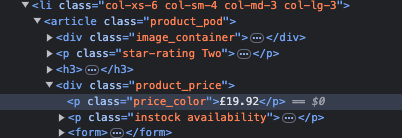

In [49]:
# Opción 1
lista_precios = soup.find_all(class_="price_color")
lista_precios

[<p class="price_color">Â£51.77</p>,
 <p class="price_color">Â£53.74</p>,
 <p class="price_color">Â£50.10</p>,
 <p class="price_color">Â£47.82</p>,
 <p class="price_color">Â£54.23</p>,
 <p class="price_color">Â£22.65</p>,
 <p class="price_color">Â£33.34</p>,
 <p class="price_color">Â£17.93</p>,
 <p class="price_color">Â£22.60</p>,
 <p class="price_color">Â£52.15</p>,
 <p class="price_color">Â£13.99</p>,
 <p class="price_color">Â£20.66</p>,
 <p class="price_color">Â£17.46</p>,
 <p class="price_color">Â£52.29</p>,
 <p class="price_color">Â£35.02</p>,
 <p class="price_color">Â£57.25</p>,
 <p class="price_color">Â£23.88</p>,
 <p class="price_color">Â£37.59</p>,
 <p class="price_color">Â£51.33</p>,
 <p class="price_color">Â£45.17</p>]

In [51]:
lista_precios[0].text

'Â£51.77'

In [53]:
lista_precios[0].text[2:]

'51.77'

In [55]:
palabra = "palabra"
palabra[4:6]

'br'

In [59]:
# Opcion 2
lista_precios_color = soup.find_all(class_="price_color")
test2 = lista_precios_color[0]
test2.get_text()[2:]

'51.77'

In [63]:
# Iteremos aplicando la opción 2
lista_precios = []
for elemento in lista_precios_color:
    precio = float(elemento.get_text()[2:])
    lista_precios.append(precio)
lista_precios

[51.77,
 53.74,
 50.1,
 47.82,
 54.23,
 22.65,
 33.34,
 17.93,
 22.6,
 52.15,
 13.99,
 20.66,
 17.46,
 52.29,
 35.02,
 57.25,
 23.88,
 37.59,
 51.33,
 45.17]

In [65]:
len(lista_precios)

20

In [ ]:
### OTRAS MANERAS

In [67]:
soup.find_all("ol", {"class": "row"})

[<ol class="row">
 <li class="col-xs-6 col-sm-4 col-md-3 col-lg-3">
 <article class="product_pod">
 <div class="image_container">
 <a href="catalogue/a-light-in-the-attic_1000/index.html"><img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/></a>
 </div>
 <p class="star-rating Three">
 <i class="icon-star"></i>
 <i class="icon-star"></i>
 <i class="icon-star"></i>
 <i class="icon-star"></i>
 <i class="icon-star"></i>
 </p>
 <h3><a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">A Light in the ...</a></h3>
 <div class="product_price">
 <p class="price_color">Â£51.77</p>
 <p class="instock availability">
 <i class="icon-ok"></i>
     
         In stock
     
 </p>
 <form>
 <button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">Add to basket</button>
 </form>
 </div>
 </article>
 </li>
 <li class="col-xs-6 col-sm-4 col-md-3 col-lg-3">
 <article class="product_pod">
 

In [69]:
soup.find_all("p", {"class": "price_color"})

[<p class="price_color">Â£51.77</p>,
 <p class="price_color">Â£53.74</p>,
 <p class="price_color">Â£50.10</p>,
 <p class="price_color">Â£47.82</p>,
 <p class="price_color">Â£54.23</p>,
 <p class="price_color">Â£22.65</p>,
 <p class="price_color">Â£33.34</p>,
 <p class="price_color">Â£17.93</p>,
 <p class="price_color">Â£22.60</p>,
 <p class="price_color">Â£52.15</p>,
 <p class="price_color">Â£13.99</p>,
 <p class="price_color">Â£20.66</p>,
 <p class="price_color">Â£17.46</p>,
 <p class="price_color">Â£52.29</p>,
 <p class="price_color">Â£35.02</p>,
 <p class="price_color">Â£57.25</p>,
 <p class="price_color">Â£23.88</p>,
 <p class="price_color">Â£37.59</p>,
 <p class="price_color">Â£51.33</p>,
 <p class="price_color">Â£45.17</p>]

In [71]:
# Otro metodo mas complejo

prices = []
for element in soup.find_all("ol", {"class": "row"}):
    for i in element.find_all("p", {"class": "price_color"}):
        prices.append(i.get_text()[2:])
prices

['51.77',
 '53.74',
 '50.10',
 '47.82',
 '54.23',
 '22.65',
 '33.34',
 '17.93',
 '22.60',
 '52.15',
 '13.99',
 '20.66',
 '17.46',
 '52.29',
 '35.02',
 '57.25',
 '23.88',
 '37.59',
 '51.33',
 '45.17']

<h1 style="color: #00BFFF;">02 | Data obtenida</h1>

In [73]:
len(lista_titulos)

20

In [75]:
len(lista_precios)

20

In [ ]:
# Crea un dataframe con estos datos

In [79]:
diccionario = {"titulo": titles,
               "precio": lista_precios}

libros_df = pd.DataFrame(data = diccionario)
libros_df

,titulo,precio
0,A Light in the Attic,51.77
1,Tipping the Velvet,53.74
2,Soumission,50.10
3,Sharp Objects,47.82
4,Sapiens: A Brief History of Humankind,54.23
5,The Requiem Red,22.65
6,The Dirty Little Secrets of Getting Your Dream Job,33.34
7,"The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull",17.93
8,The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics,22.60
9,The Black Maria,52.15


<h1 style="color: #00BFFF;">Otro ejemplo: Caso de Uso 2</h1>

<h1 style="color: #00BFFF;">01 | Data Extraction</h1>

In [81]:
response = requests.get('https://en.wikipedia.org/wiki/Silicon_Valley_(TV_series)')
response.status_code

200

In [83]:
html = response.text

In [85]:
html

'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 vector-feature-night-mode-enabled skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available" lang="en" dir="ltr">\n<head>\n<meta charset="UTF-8">\n<title>Silicon Valley (TV series) - Wikipedia</title>\n<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-e

In [87]:
soup = BeautifulSoup(html, 'html.parser')

BeautifulSoup permite filtrar resultados usando combinaciones, como por ejemplo filtrando por etiqueta y clase.

```python
tags = soup.find_all(name=tag_name, class_=class_name)
```

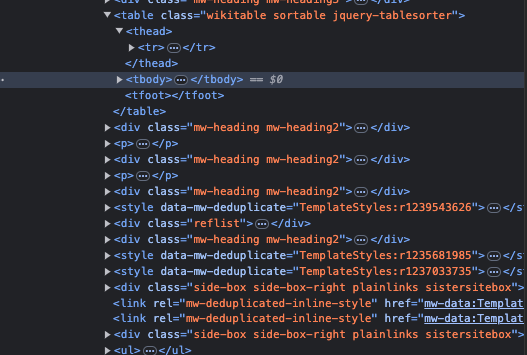

In [89]:
html_table = soup.find("table", {"class": "wikitable sortable"})

In [91]:
html_table

<table class="wikitable sortable">
<tbody><tr>
<th align="left">Year
</th>
<th align="left">Ceremony
</th>
<th align="left">Category
</th>
<th align="left">Recipients
</th>
<th align="left">Result
</th></tr>
<tr>
<td rowspan="9" style="text-align:center;">2014
</td>
<td><a href="/wiki/South_by_Southwest" title="South by Southwest">SXSW Audience Award</a><sup class="reference" id="cite_ref-53"><a href="#cite_note-53"><span class="cite-bracket">[</span>53<span class="cite-bracket">]</span></a></sup>
</td>
<td>Episodic
</td>
<td><a href="/wiki/Mike_Judge" title="Mike Judge">Mike Judge</a>
</td>
<td class="yes table-yes2 notheme" style="background: #9EFF9E; color: #000; vertical-align: middle; text-align: center;">Won
</td></tr>
<tr>
<td rowspan="3"><a href="/wiki/4th_Critics%27_Choice_Television_Awards" title="4th Critics' Choice Television Awards">4th Critics' Choice Television Awards</a><sup class="reference" id="cite_ref-54"><a href="#cite_note-54"><span class="cite-bracket">[</span>54

In [ ]:
# Otra opcion: html_table = soup.find_all("table", {"class": "wikitable sortable"})[0]

Para extraer los nombres del contenido HTML proporcionado, puedes:

1. Usar el método `find_all` o `findAll` para localizar las etiquetas `<h4>` con la clase específica (`de-ProductTile-title` en este caso).
2. Extraer el texto de la etiqueta encontrada.


<h1 style="color: #00BFFF;">02 | Data obtenida</h1>

In [93]:
html_pretty = html_table.prettify()
print(html_pretty)

<table class="wikitable sortable">
 <tbody>
  <tr>
   <th align="left">
    Year
   </th>
   <th align="left">
    Ceremony
   </th>
   <th align="left">
    Category
   </th>
   <th align="left">
    Recipients
   </th>
   <th align="left">
    Result
   </th>
  </tr>
  <tr>
   <td rowspan="9" style="text-align:center;">
    2014
   </td>
   <td>
    <a href="/wiki/South_by_Southwest" title="South by Southwest">
     SXSW Audience Award
    </a>
    <sup class="reference" id="cite_ref-53">
     <a href="#cite_note-53">
      <span class="cite-bracket">
       [
      </span>
      53
      <span class="cite-bracket">
       ]
      </span>
     </a>
    </sup>
   </td>
   <td>
    Episodic
   </td>
   <td>
    <a href="/wiki/Mike_Judge" title="Mike Judge">
     Mike Judge
    </a>
   </td>
   <td class="yes table-yes2 notheme" style="background: #9EFF9E; color: #000; vertical-align: middle; text-align: center;">
    Won
   </td>
  </tr>
  <tr>
   <td rowspan="3">
    <a href="/wiki/4t

In [95]:
df2 = pd.read_html(html_pretty)[0]
df2

,Year,Ceremony,Category,Recipients,Result
0,2014,SXSW Audience Award [ 53 ],Episodic,Mike Judge,Won
1,2014,4th Critics' Choice Television Awards [ 54 ],Best Comedy Series,Silicon Valley,Nominated
2,2014,4th Critics' Choice Television Awards [ 54 ],Best Actor in a Comedy Series,Thomas Middleditch,Nominated
3,2014,4th Critics' Choice Television Awards [ 54 ],Best Supporting Actor in a Comedy Series,Christopher Evan Welch,Nominated
4,2014,66th Primetime Emmy Awards [ 55 ],Outstanding Comedy Series,Silicon Valley,Nominated
...,...,...,...,...,...
62,2018,70th Primetime Emmy Awards [ 72 ],Outstanding Writing for a Comedy Series,"Alec Berg for ""Fifty-One Percent""",Nominated
63,2019,23rd Satellite Awards [ 73 ],Best Actor in a Musical or Comedy Series,Thomas Middleditch,Nominated
64,2019,17th Visual Effects Society Awards [ 74 ],Outstanding Compositing in a Photoreal Episode,"Tim Carras, Michael Eng, Shiying Li, Bill Parker for ""Artificial Emotional Intelligence"" – Fiona",Nominated
65,2020,24th Satellite Awards [ 75 ],Best Actor in a Musical or Comedy Series,Thomas Middleditch,Won


<h1 style="color: #00BFFF;">Selectores CSS</h1>

Los selectores CSS son patrones usados para seleccionar y manipular uno o más elementos en un documento HTML o XML.  
Cuando hacemos web scraping con Python, los selectores CSS pueden usarse para apuntar a elementos específicos dentro del contenido de la página.


El método `select` en BeautifulSoup permite pasar un selector CSS y devuelve una lista de elementos que coinciden con ese selector.


1. **Selector por etiqueta**: Selecciona elementos por su nombre de etiqueta.
   - `p`: selecciona todos los elementos `<p>`.
   - `soup.select("p")` devolverá todos los elementos `<p>`.

2. **Selector por clase**: Selecciona elementos por su atributo `class`.
   - `.classname`: selecciona todos los elementos con `class="classname"`.
   - Si el nombre de clase tiene espacios, deben reemplazarse por `.`.
   - `soup.select(".classname")`
   - Para combinar ambos, se puede usar: `soup.select("tagname.classname")`

3. **Selector de descendientes**: Selecciona un elemento que es descendiente de otro.
   - `div p`: selecciona todos los elementos `<p>` dentro de un `<div>`.
   - `.class1 .class2`: selecciona todos los elementos con `class2` que son descendientes de un elemento con `class1`.

4. **Selector por atributo**: Selecciona elementos basados en sus atributos y valores.
   - `a[href]`: selecciona todos los elementos `<a>` que tienen un atributo `href`.
   - `a[href="https://www.example.com"]`: selecciona todos los elementos `<a>` con un valor `href` igual a "https://www.example.com".


![legtsgo](https://i.giphy.com/media/v1.Y2lkPTc5MGI3NjExcGo0MzlvbzI1cHFtZXo2eDNucHo4NGd4dzUzNXFxeWhvbDd4czdiMyZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/9O2h5v3hqeSGNmKgDV/giphy.gif)

#### Usando selectores CSS

Un paso a la vez:

- Vamos a aprender primero la sintaxis de los selectores CSS jugando a este juego: https://flukeout.github.io/

**¡Todos deben llegar al nivel 8!**
